In [9]:
from kafka import KafkaConsumer
import pandas as pd
import json
import numpy as np
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from IPython.display import display, SVG, Image
load_dotenv()

True

In [10]:
KAFKA_PORT=os.getenv("KAFKA_PORT", 9092)
topic = "user-interactions"
consumer = KafkaConsumer(
    topic, 
    enable_auto_commit=True,
    value_deserializer=lambda x: json.loads(x.decode('utf-8')),
    auto_offset_reset='earliest',
    bootstrap_servers=['localhost:9092'])
messages=consumer.poll(timeout_ms=1000,max_records=10000)
df = []
for m in messages.values():
    for i in m:
        df.append(i.value)
df = pd.DataFrame(df)
# explode metadata col json
df = df.join(pd.json_normalize(df.pop("metadata"), sep=".").add_prefix("metadata_"))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 528 entries, 0 to 527
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sessionId           528 non-null    object 
 1   eventType           467 non-null    object 
 2   ts                  528 non-null    object 
 3   targetEl            401 non-null    object 
 4   eventName           61 non-null     object 
 5   page                61 non-null     object 
 6   storeMode           61 non-null     object 
 7   userAgent           61 non-null     object 
 8   productId           21 non-null     object 
 9   metadata_path       467 non-null    object 
 10  metadata_referrer   82 non-null     object 
 11  metadata_x          425 non-null    float64
 12  metadata_y          425 non-null    float64
 13  metadata_event      7 non-null      object 
 14  metadata_targetEl   24 non-null     object 
 15  metadata_roomType   5 non-null      object 
 16  metadata

In [11]:
df.groupby('sessionId').head()

,sessionId,eventType,ts,targetEl,eventName,page,storeMode,userAgent,productId,metadata_path,metadata_referrer,metadata_x,metadata_y,metadata_event,metadata_targetEl,metadata_roomType,metadata_price,metadata_nights,metadata_targetUrl
0,1762434923440-66hdhq8qicd,pageview,1762434924107,NaN,NaN,NaN,NaN,NaN,NaN,/,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1762434923440-66hdhq8qicd,click,1762434925198,DIV,NaN,NaN,NaN,NaN,NaN,/,NaN,1098.0,663.0,NaN,NaN,NaN,NaN,NaN,NaN
2,1762434923440-66hdhq8qicd,click,1762434925371,MAIN,NaN,NaN,NaN,NaN,NaN,/,NaN,1098.0,663.0,NaN,NaN,NaN,NaN,NaN,NaN
3,1762434923440-66hdhq8qicd,pageview,1762437192910,NaN,NaN,NaN,NaN,NaN,NaN,/,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1762434923440-66hdhq8qicd,pageview,1762437198539,NaN,NaN,NaN,NaN,NaN,NaN,/,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
390,d423ce8a-77aa-4c9a-94d4-d1adddcc3472,click,1762443115648,DIV,NaN,NaN,NaN,NaN,NaN,/,NaN,245.0,595.0,NaN,NaN,NaN,NaN,NaN,NaN
391,d423ce8a-77aa-4c9a-94d4-d1adddcc3472,click,1762443174606,DIV,NaN,NaN,NaN,NaN,NaN,/,NaN,475.0,428.0,NaN,NaN,NaN,NaN,NaN,NaN
392,d423ce8a-77aa-4c9a-94d4-d1adddcc3472,click,1762443183406,INPUT,NaN,NaN,NaN,NaN,NaN,/,NaN,832.0,219.0,NaN,NaN,NaN,NaN,NaN,NaN
393,d423ce8a-77aa-4c9a-94d4-d1adddcc3472,click,1762443208588,DIV,NaN,NaN,NaN,NaN,NaN,/,NaN,485.0,155.0,NaN,NaN,NaN,NaN,NaN,NaN
394,d423ce8a-77aa-4c9a-94d4-d1adddcc3472,click,1762443225474,DIV,NaN,NaN,NaN,NaN,NaN,/,NaN,281.0,281.0,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
sessions = list(set(df['sessionId'])); sessions

['214d9fad-9b00-40c3-bd0e-7739b6acd654',
 '1762444018243-0120z6z5u42f',
 'f0d40ca6-c1d3-4ecd-beb3-796adc74349d',
 'd423ce8a-77aa-4c9a-94d4-d1adddcc3472',
 '1762434923440-66hdhq8qicd']

In [13]:
# map sessions to experiments

In [17]:
def build_transition_prob_matrix(df: pd.DataFrame):
    df = df.dropna(subset=['eventName'])
    events = df['eventName'].tolist()
    labels = pd.Index(events).unique().tolist()
    idx = {e:i for i,e in enumerate(labels)}
    M = np.zeros((len(labels), len(labels)), dtype=float)
    for a, b in zip(events, events[1:]):
        M[idx[a], idx[b]] += 1
    row_sums = M.sum(axis=1, keepdims=True)
    with np.errstate(divide='ignore', invalid='ignore'):
        P = np.divide(M, row_sums, where=row_sums>0)  # row-normalized
    return P, labels

In [18]:
# https://medium.com/data-science/time-series-data-markov-transition-matrices-7060771e362b
from graphviz import Digraph
import numpy as np
import pandas as pd

def _as_prob_df(matrix, labels=None):
    """Return a square DataFrame with index=columns=labels."""
    if isinstance(matrix, pd.DataFrame):
        # Ensure square and aligned
        assert (matrix.index == matrix.columns).all(), "Index/columns must match."
        return matrix
    matrix = np.asarray(matrix, dtype=float)
    assert matrix.shape[0] == matrix.shape[1], "Matrix must be square."
    if labels is None:
        raise ValueError("labels are required when matrix is not a DataFrame")
    assert len(labels) == matrix.shape[0], "labels length must match matrix size."
    return pd.DataFrame(matrix, index=list(labels), columns=list(labels))

def _df_to_edgelist(P: pd.DataFrame, threshold=0.0, round_digits=2):
    """Build weighted edges > threshold."""
    edges = []
    for src in P.index:
        for dst in P.columns:
            w = float(P.loc[src, dst])
            if w > threshold:
                edges.append((str(src), str(dst), f"{w:.{round_digits}f}"))
    return edges

def render_graph(fname, matrix, ls_index=None, threshold=0.0, fmt="svg", view=False):
    """
    fname: output file stem (no extension)
    matrix: NumPy array or pandas DataFrame of transition PROBABILITIES
    ls_index: ordered labels (required if matrix is not a DataFrame)
    threshold: hide edges with weight <= threshold
    fmt: 'svg'|'png'|'pdf' etc.
    view: open after rendering
    """
    P = _as_prob_df(matrix, labels=ls_index)
    edges = _df_to_edgelist(P, threshold=threshold)

    g = Digraph(format=fmt)
    g.attr(rankdir="LR", size="30")
    g.attr("node", shape="circle")

    # ensure isolated nodes appear
    for node in P.index:
        g.node(str(node), width="1", height="1")

    for src, dst, label in edges:
        g.edge(src, dst, label=label)

    g.render(fname, view=view, cleanup=True)
    return g


[]


[]


[]


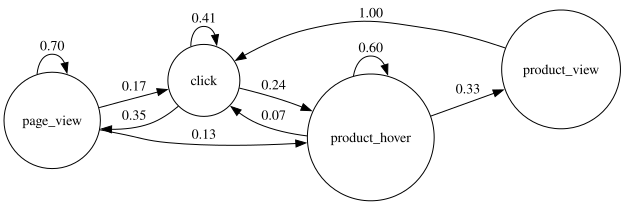

[[0.69565217 0.17391304 0.13043478 0.        ]
 [0.35294118 0.41176471 0.23529412 0.        ]
 [0.         0.06666667 0.6        0.33333333]
 [0.         1.         0.         0.        ]]


[]


In [19]:
def explore_session(session_id: str):
    subset = df[df['sessionId'] == session_id]
    P, labels = build_transition_prob_matrix(subset)
    g = render_graph(f"session_{session_id}", P, ls_index=labels, threshold=0.01, fmt="svg", view=False)
    display(g)
    return P
for session in sessions:
    print(explore_session(session))